In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

from tqdm import tqdm

from lib.algorithms.unconstrained import gradient_descent, nesterov, triple_momentum
from lib.analysis.run_solver import static_IQC_rho_bisection, var_IQC_rho_bisection, var_IQC_rho_sweep
from lib.analysis.polytope import consistent_polytope_nd

In [2]:
# Plot settings
tableau10 = plt.get_cmap('tab10').colors
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# helper function to extract certificates
def extract_certificate_arrays(cert_list):
    rhos         = np.array([d['rho']            for d in cert_list])
    c1_vals      = np.array([d['c1']             for d in cert_list])
    c2_vals      = np.array([d['c2']             for d in cert_list])
    gamma_f_vals = np.array([sum(float(l) for l in d['lambda_f']) for d in cert_list])
    gamma_x_vals = np.array([d['sensitivity_x']  for d in cert_list])
    gamma_g_vals = np.array([d['sensitivity_g']  for d in cert_list])
    return rhos, c1_vals, c2_vals, gamma_f_vals, gamma_x_vals, gamma_g_vals

In [ ]:
# Define some multi-step algorithms
two_step_gd  = lambda m, L: gradient_descent(m,L,K=2)
five_step_gd = lambda m, L: gradient_descent(m,L,K=5)

two_step_nm = lambda m, L: nesterov(m,L,K=2)

## 1 - Comparison of Theorem 5.1 and 5.4

Comparing minimum contraction rates $\rho$ for different algorithms

In [ ]:
L_range = np.logspace(0, 2, 10)

rhos_gd_sIQC, rhos_2gd_sIQC, rhos_nm_sIQC = [], [], []
rhos_gd_vIQC, rhos_2gd_vIQC, rhos_nm_vIQC = [], [], []

for L in tqdm(L_range):

    ### Assume constant L (and m=1)
    grid_points = [(np.array([L]), np.array([0]))]

    ### Solve Bisection for Theorem 5.1
    sol_gd_s  = static_IQC_rho_bisection(gradient_descent, grid_points, only_L=True)
    sol_2gd_s = static_IQC_rho_bisection(two_step_gd,      grid_points, only_L=True)
    sol_nm_s  = static_IQC_rho_bisection(nesterov,         grid_points, only_L=True)

    ### Solve Bisection for Theorem 5.4
    sol_gd_v  = var_IQC_rho_bisection(gradient_descent, grid_points, only_L=True)
    sol_2gd_v = var_IQC_rho_bisection(two_step_gd,      grid_points, only_L=True)
    sol_nm_v  = var_IQC_rho_bisection(nesterov,         grid_points, only_L=True)

    rhos_gd_sIQC.append(sol_gd_s["rho"])
    rhos_2gd_sIQC.append(sol_2gd_s["rho"])
    rhos_nm_sIQC.append(sol_nm_s["rho"])
    rhos_gd_vIQC.append(sol_gd_v["rho"])
    rhos_2gd_vIQC.append(sol_2gd_v["rho"])
    rhos_nm_vIQC.append(sol_nm_v["rho"])

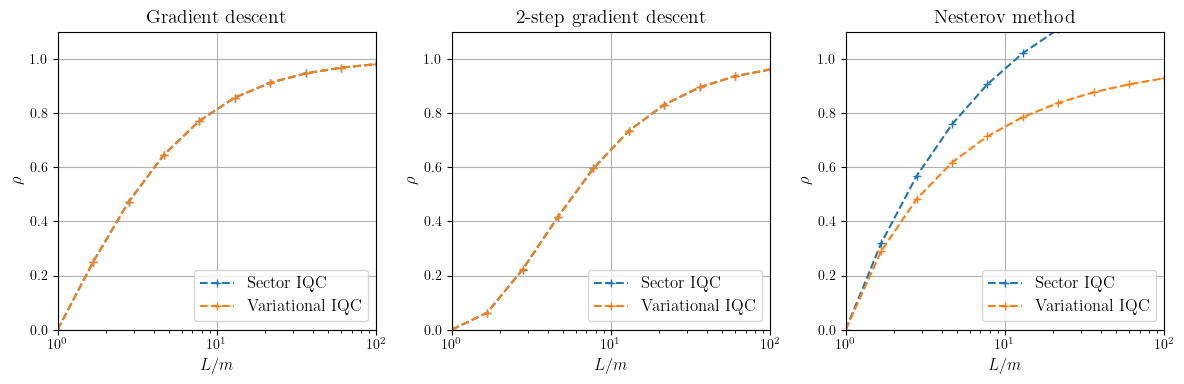

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

# Plot gradient descent
axes[0].semilogx(L_range, rhos_gd_sIQC,'--+', label='Sector IQC',      color=tableau10[0])
axes[0].semilogx(L_range, rhos_gd_vIQC,'--+', label='Variational IQC', color=tableau10[1])
axes[0].set_title("Gradient descent")

# Plot 2-step gradient descent
axes[1].semilogx(L_range, rhos_2gd_sIQC,'--+', label='Sector IQC',      color=tableau10[0])
axes[1].semilogx(L_range, rhos_2gd_vIQC,'--+', label='Variational IQC', color=tableau10[1])
axes[1].set_title("2-step gradient descent")

# Plot nesterov
axes[2].semilogx(L_range, rhos_nm_sIQC,'--+', label='Sector IQC',      color=tableau10[0])
axes[2].semilogx(L_range, rhos_nm_vIQC,'--+', label='Variational IQC', color=tableau10[1])
axes[2].set_title("Nesterov method")

for ax in axes:
    ax.set_xlabel(r'$L/m$')
    ax.set_ylabel(r'$\rho$')
    ax.set_xlim([1, 100])
    ax.set_ylim([0, 1.1])
    ax.grid()
    ax.legend(loc='lower right')
    

plt.tight_layout()
plt.show()

### Observations:

- for gradient-based methods, Theorem 5.1 is already sufficient to get a tight result
- for accelerated methods, Theorem 5.4 offers substantial improvements

## 2 - Comparison of algorithms

### 2a) Decay rate $\rho$

In [ ]:
L_range = np.logspace(0, 2, 10)

rhos_ogd, rhos_nm, rhos_tmm, rhos_2gd, rhos_5gd, rhos_2nm = [], [], [], [], [], []

for L in tqdm(L_range):

    ### Assume constant L (and m=1)
    grid_points = [(np.array([L]), np.array([0]))]

    # Thm: sector IQC
    sol_ogd = static_IQC_rho_bisection(gradient_descent, grid_points, only_L=True)
    sol_2gd = static_IQC_rho_bisection(two_step_gd,      grid_points, only_L=True)
    sol_5gd = static_IQC_rho_bisection(five_step_gd,     grid_points, only_L=True)

    # Thm: variational IQC
    sol_nm  = var_IQC_rho_bisection(nesterov,        grid_points, only_L=True)
    sol_2nm = var_IQC_rho_bisection(two_step_nm,     grid_points, only_L=True)
    sol_tmm = var_IQC_rho_bisection(triple_momentum, grid_points, only_L=True)

    rhos_ogd.append(sol_ogd["rho"])
    rhos_2gd.append(sol_2gd["rho"])
    rhos_5gd.append(sol_5gd["rho"])
    rhos_nm.append(sol_nm["rho"])
    rhos_2nm.append(sol_2nm["rho"])
    rhos_tmm.append(sol_tmm["rho"])

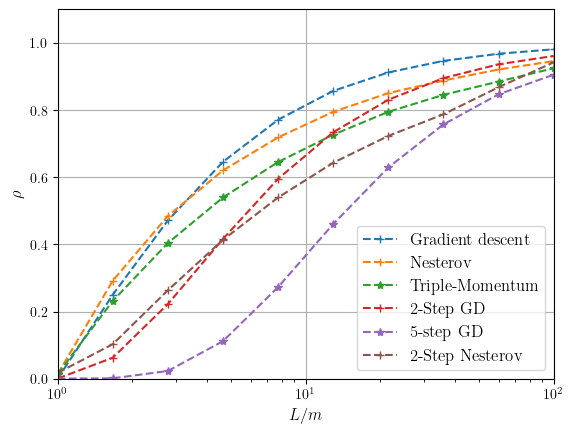

In [ ]:
### Plot results
plt.semilogx(L_range, rhos_ogd, '--+', label=r'Gradient descent', color=tableau10[0])
plt.semilogx(L_range,  rhos_nm, '--+', label=r'Nesterov',         color=tableau10[1])
plt.semilogx(L_range, rhos_tmm, '--*', label=r'Triple-Momentum',  color=tableau10[2])
plt.semilogx(L_range, rhos_2gd, '--+', label=r'2-Step GD',        color=tableau10[3])
plt.semilogx(L_range, rhos_5gd, '--*', label=r'5-step GD',        color=tableau10[4])
plt.semilogx(L_range, rhos_2nm, '--+', label=r'2-Step Nesterov',  color=tableau10[5])

plt.xlabel(r'$L/m$')
plt.ylabel(r'$\rho$')

plt.xlim([1,100])
plt.ylim([0,1.1])

plt.legend(loc='lower right')
plt.grid()
plt.show()


### 2b) Sensitivities 

- $\gamma_f$: Sensitivitiy to function variation
- $\gamma_x$: Sensitivitiy to minimizer variation
- $\gamma_\delta$: Sensititivity to gradient variation

In [17]:
L_range = np.logspace(0, 2, 10)

sol_gd, sol_nm, sol_tmm, sol_2gd, sol_5gd = [], [], [], [], []

for L in tqdm(L_range):

    ### Assume constant L (and m=1)
    grid_points = [(np.array([L]), np.array([0]))]

    ### Solve with Thm 5.3 to obtain sensitivities
    cert_gd  = var_IQC_rho_bisection(gradient_descent, grid_points, optimize_bound=True, only_L=True)
    cert_5gd = var_IQC_rho_bisection(five_step_gd,     grid_points, optimize_bound=True, only_L=True)
    cert_nm  = var_IQC_rho_bisection(nesterov,         grid_points, optimize_bound=True, only_L=True)
    cert_tmm = var_IQC_rho_bisection(triple_momentum,  grid_points, optimize_bound=True, only_L=True)

    sol_gd.append(cert_gd)
    sol_5gd.append(cert_5gd)
    sol_nm.append(cert_nm)
    sol_tmm.append(cert_tmm)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [04:09<00:00, 24.99s/it]


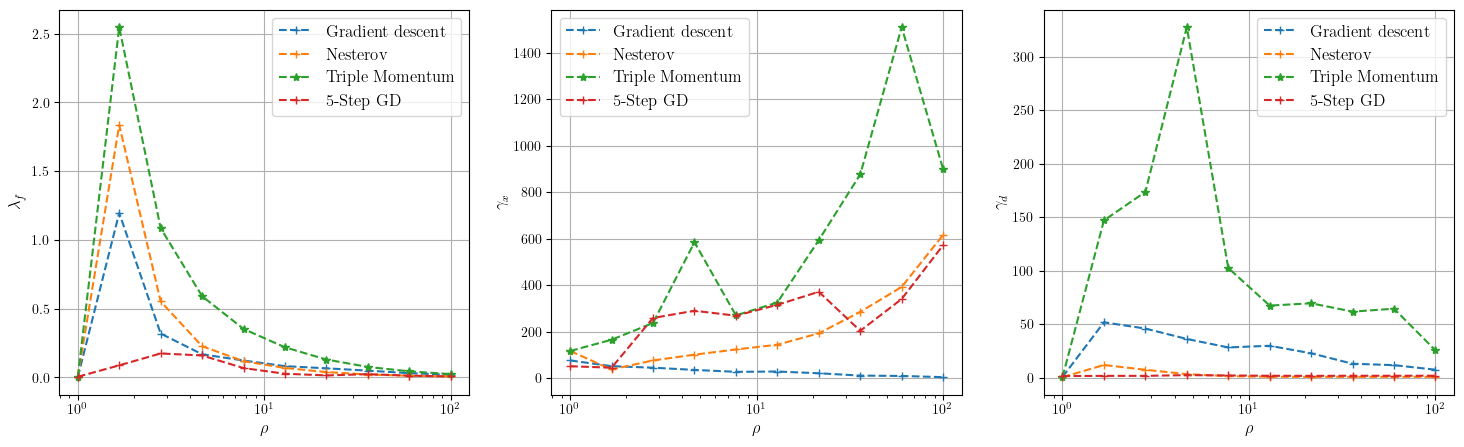

In [18]:
# extract quantities to plot
_, _, _, gamma_f_gd,  gamma_x_gd,  gamma_g_gd  = extract_certificate_arrays(sol_gd)
_, _, _, gamma_f_nm,  gamma_x_nm,  gamma_g_nm  = extract_certificate_arrays(sol_nm)
_, _, _, gamma_f_tmm, gamma_x_tmm, gamma_g_tmm = extract_certificate_arrays(sol_tmm)
_, _, _, gamma_f_5gd, gamma_x_5gd, gamma_g_5gd = extract_certificate_arrays(sol_5gd)   

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

axes[0].semilogx(L_range, gamma_f_gd,  '--+', label='Gradient descent', color=tableau10[0])
axes[0].semilogx(L_range, gamma_f_nm,  '--+', label='Nesterov',         color=tableau10[1])
axes[0].semilogx(L_range, gamma_f_tmm, '--*', label='Triple Momentum',  color=tableau10[2])
axes[0].semilogx(L_range, gamma_f_5gd, '--+', label='5-Step GD',        color=tableau10[3])
axes[0].set_ylabel(r'$\lambda_f$')


axes[1].semilogx(L_range, gamma_x_gd,  '--+', label='Gradient descent', color=tableau10[0])
axes[1].semilogx(L_range, gamma_x_nm,  '--+', label='Nesterov',         color=tableau10[1])
axes[1].semilogx(L_range, gamma_x_tmm, '--*', label='Triple Momentum',  color=tableau10[2])
axes[1].semilogx(L_range, gamma_x_5gd, '--+', label='5-Step GD',        color=tableau10[3])
axes[1].set_ylabel(r'$\gamma_x$')

axes[2].semilogx(L_range, gamma_g_gd, '--+', label='Gradient descent', color=tableau10[0])
axes[2].semilogx(L_range, gamma_g_nm, '--+', label='Nesterov',         color=tableau10[1])
axes[2].semilogx(L_range, gamma_g_tmm, '--*', label='Triple Momentum', color=tableau10[2])
axes[2].semilogx(L_range, gamma_g_5gd, '--+', label='5-Step GD',       color=tableau10[3])
axes[2].set_ylabel(r'$\gamma_d$')

for ax in axes.flat:
    if ax.get_visible():
        ax.set_xlabel(r'$\rho$')
        ax.grid(True)
        ax.legend()

# plt.tight_layout()
plt.show()


## 3 - Varying-Parameter Setting $\overline{\nu}$

In [ ]:
L_range = np.logspace(np.log10(1/0.8 + 1e-3), 2, 10)

rhos_fast_gd, rhos_middle_gd, rhos_slow_gd, rho_nom_gd = (list() for _ in range(4))
rhos_fast_nag, rhos_middle_nag, rhos_slow_nag, rho_nom_nag = (list() for _ in range(4))

# grid samples
n_grid = 5

for L in tqdm(L_range):

    ### Create consistent polytope grid over parameters
    L_min, L_max = L * 0.8, L
    grid_step = (L_max - L_min) / n_grid

    params = np.linspace(L_min, L_max, n_grid + 1)

    delta_L_max = lambda rate_bound: rate_bound * (L_max - L_min)

    grid_points_fast = consistent_polytope_nd(
                        params,
                        -delta_L_max(rate_bound=1),
                        delta_L_max(rate_bound=1),
                        step_size=grid_step)
    grid_points_mod = consistent_polytope_nd(
                        params,
                        -delta_L_max(rate_bound=0.5),
                        delta_L_max(rate_bound=0.5),
                        step_size=grid_step)
    grid_points_slow = consistent_polytope_nd(
                        params,
                        -delta_L_max(rate_bound=0.05),
                        delta_L_max(rate_bound=0.05),
                        step_size=grid_step)
    grid_static = [(np.array([L]), np.array([0]))]

    ### gradient descent
    sol_fast = static_IQC_rho_bisection(gradient_descent, grid_points_fast, False, only_L=True)
    sol_mod  = static_IQC_rho_bisection(gradient_descent, grid_points_mod,  False, only_L=True)
    sol_slow = static_IQC_rho_bisection(gradient_descent, grid_points_slow, False, only_L=True)
    sol_nom  = static_IQC_rho_bisection(gradient_descent, grid_static,      False, only_L=True)

    rhos_fast_gd.append(sol_fast["rho"])
    rhos_middle_gd.append(sol_mod["rho"])
    rhos_slow_gd.append(sol_slow["rho"])
    rho_nom_gd.append(sol_nom["rho"])

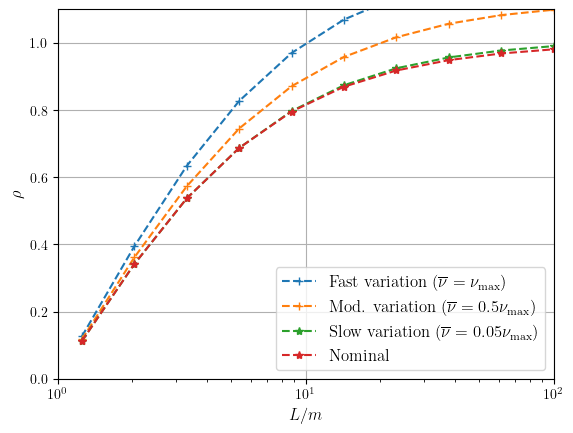

In [ ]:
plt.semilogx(L_range, rhos_fast_gd,   '--+', label=r'Fast variation ($\overline{\nu} = \nu_{\max}$)',      color=tableau10[0])
plt.semilogx(L_range, rhos_middle_gd, '--+', label=r'Mod. variation ($\overline{\nu} = 0.5\nu_{\max}$)',   color=tableau10[1])
plt.semilogx(L_range, rhos_slow_gd,   '--*', label=r'Slow variation ($\overline{\nu} = 0.05\nu_{\max}$)',  color=tableau10[2])
plt.semilogx(L_range, rho_nom_gd,     '--*', label=r'Nominal',                                             color=tableau10[3])


plt.xlabel(r'$L/m$')
plt.ylabel(r'$\rho$')
plt.xlim([1, 100])
plt.ylim([0, 1.1])
plt.grid(True)
plt.legend()

plt.show()


## 4 - Certificate Trade-offs: $\rho$ vs. bound constants

For a fixed problem (fixed $L/m$), the SDP is solved at many values of $rho$.
Each feasible $rho$ yields a different set of bound constants $(c_1, c_2, \gamma_f, \gamma_x, \gamma_\delta)$.
A smaller $rho$ (faster decay) requires larger constants (greater sensitivity to objective variation).

In [ ]:
# Fixed problem: L/m = 10 (constant objective, m=1)
L_fixed = 10.0
grid_points = [(np.array([L_fixed]), np.array([0]))]

# Sweep rho for each algorithm (Varying IQC / Theorem 5.3)
certs_gd  = var_IQC_rho_sweep(gradient_descent, grid_points, rho_lo=0.1, rho_hi=0.98, rho_step=0.02, only_L=True)
certs_nm  = var_IQC_rho_sweep(nesterov,         grid_points, rho_lo=0.1, rho_hi=0.98, rho_step=0.02, only_L=True)
certs_tmm = var_IQC_rho_sweep(triple_momentum,  grid_points, rho_lo=0.1, rho_hi=0.98, rho_step=0.02, only_L=True)

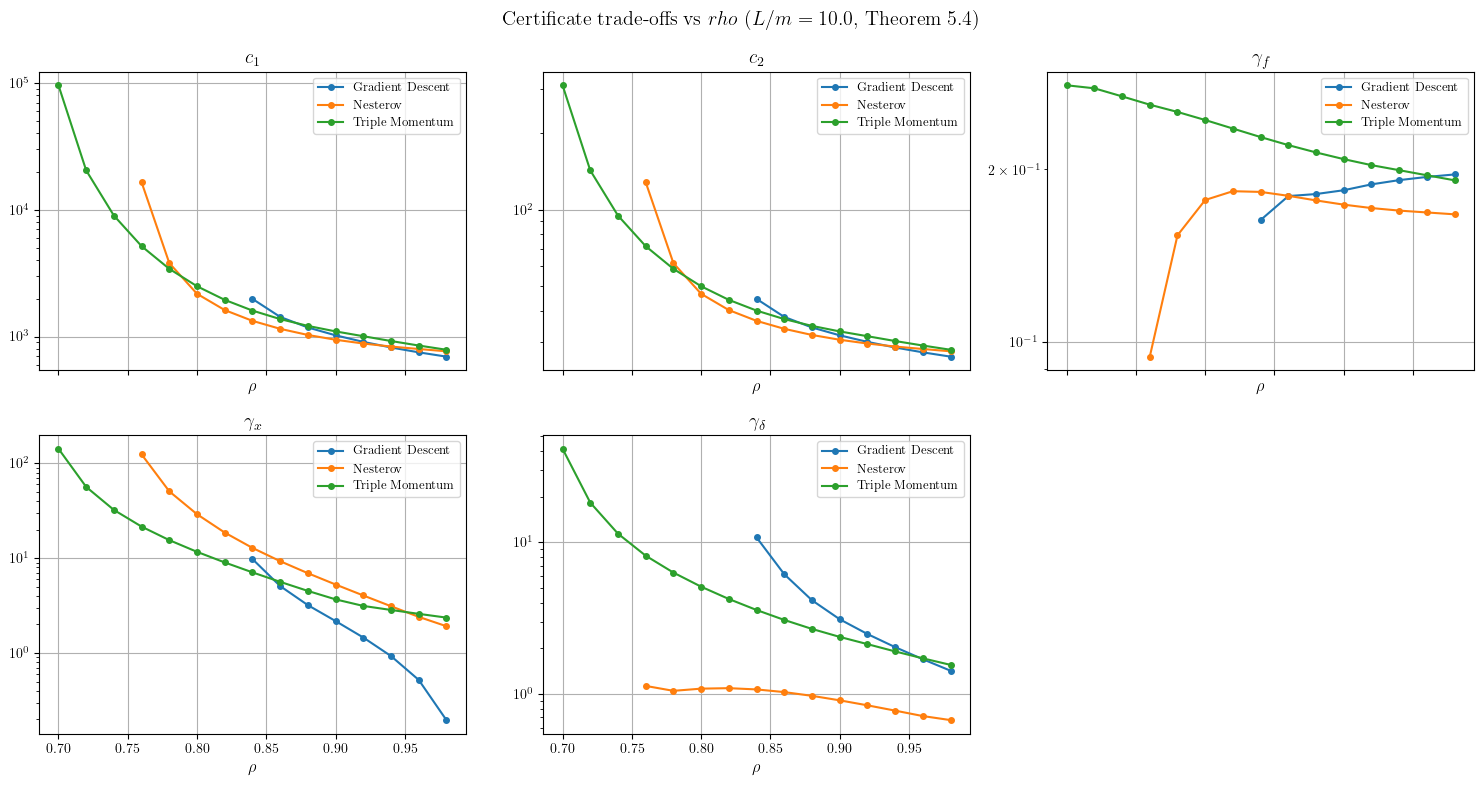

In [ ]:
# extract quantities to plot
rhos_gd,  c1_gd,  c2_gd,  gamma_f_gd,  gamma_x_gd,  gamma_g_gd  = extract_certificate_arrays(certs_gd)
rhos_nm,  c1_nm,  c2_nm,  gamma_f_nm,  gamma_x_nm,  gamma_g_nm  = extract_certificate_arrays(certs_nm)
rhos_tmm, c1_tmm, c2_tmm, gamma_f_tmm, gamma_x_tmm, gamma_g_tmm = extract_certificate_arrays(certs_tmm)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fig.suptitle(rf'Certificate trade-offs vs $rho$ ($L/m = {L_fixed}$, Theorem 5.4)')

algo_data = [
    ('Gradient Descent', rhos_gd,  c1_gd,  c2_gd,  gamma_f_gd,  gamma_x_gd,  gamma_g_gd,  tableau10[0]),
    ('Nesterov',         rhos_nm,  c1_nm,  c2_nm,  gamma_f_nm,  gamma_x_nm,  gamma_g_nm,  tableau10[1]),
    ('Triple Momentum',  rhos_tmm, c1_tmm, c2_tmm, gamma_f_tmm, gamma_x_tmm, gamma_g_tmm, tableau10[2]),
]

for label, rhos, c1_vals, c2_vals, gamma_f_vals, gamma_x_vals, gamma_g_vals, color in algo_data:
    axes[0, 0].semilogy(rhos, c1_vals,      '-o', label=label, color=color, markersize=4)
    axes[0, 1].semilogy(rhos, c2_vals,      '-o', label=label, color=color, markersize=4)
    axes[0, 2].semilogy(rhos, gamma_f_vals, '-o', label=label, color=color, markersize=4)
    axes[1, 0].semilogy(rhos, gamma_x_vals, '-o', label=label, color=color, markersize=4)
    axes[1, 1].semilogy(rhos, gamma_g_vals, '-o', label=label, color=color, markersize=4)

axes[0, 0].set_title(r'$c_1$')
axes[0, 1].set_title(r'$c_2$')
axes[0, 2].set_title(r'$\gamma_f$')
axes[1, 0].set_title(r'$\gamma_x$')
axes[1, 1].set_title(r'$\gamma_\delta$')
axes[1, 2].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.set_xlabel(r'$\rho$')
        ax.grid(True)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()